#Mental Health Sentiment Analysis
 This project builds a machine learning model to classify user text into mental health conditions such as Anxiety, Depression, and Suicidal.

The goal is to create a reliable base model for an AI-powered mental health assistant.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

# Loading Dataset
The dataset contains user statements labeled with mental health conditions.

- Total Samples: 26,350  
- Classes: 7  
- Columns:
  - `statement` → user text  
  - `status` → mental condition  

In [40]:
df= pd.read_csv("Sentiment_Mental_health_dataset.csv")

In [41]:
df.head()

,statement,status
0,Anyone else have symptoms much improved after ...,Bipolar
1,"I basicaly do not exist, sure feels that way. ...",Suicidal
2,Finding a sense of self It's like one minute I...,Personality_disorder
3,Putting into words what were just tangles in m...,Anxiety
4,Anxiety makes me worry about my public image s...,Anxiety


# Data Exploration

- Checked dataset structure and data types  
- No missing values found  
- Data is clean and ready for preprocessing

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26350 entries, 0 to 26349
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  26350 non-null  object
 1   status     26350 non-null  object
dtypes: object(2)
memory usage: 411.8+ KB


In [43]:
df.describe()

,statement,status
count,26350,26350
unique,26329,7
top,.,Suicidal
freq,4,5600


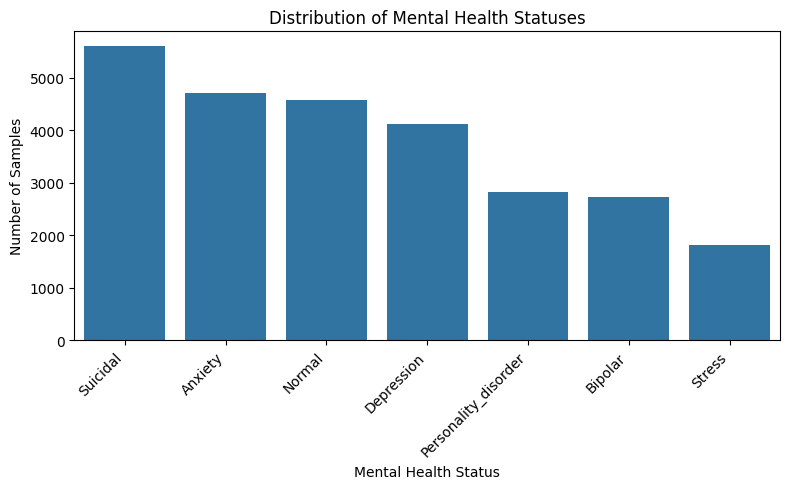

In [44]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index)
plt.title('Distribution of Mental Health Statuses')
plt.xlabel('Mental Health Status')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [45]:
df.shape

(26350, 2)

# Class Distribution

The dataset shows moderate class imbalance.

- Suicidal class has highest samples  
- Stress class has lowest samples  


In [46]:
df['status'].value_counts()

,count
status,
Suicidal,5600
Anxiety,4704
Normal,4575
Depression,4111
Personality_disorder,2817
Bipolar,2720
Stress,1823


## Text Preprocessing
The text data was cleaned using the following steps:

- Converted text to lowercase  
- Expanded the words
- Removed punctuation and special characters  
- Tokenized text  
- Removed stopwords  
- Applied POS-based lemmatization  

This ensures standardized and meaningful input for the model.

In [47]:
df['statement']= df['statement'].str.lower()

In [48]:
!pip install contractions

In [49]:
import contractions
df['statement'] = df['statement'].apply(lambda x: contractions.fix(x))
print(df['statement'].head())

0    anyone else have symptoms much improved after ...
1    i basicaly do not exist, sure feels that way. ...
2    finding a sense of self it is like one minute ...
3    putting into words what were just tangles in m...
4    anxiety makes me worry about my public image s...
Name: statement, dtype: object


In [50]:
import re
df['statement'] = df['statement'].str.replace(r'[^\w\s]', '', regex=True)
df['statement'] = df['statement'].str.replace(r"http\S+|www\S+|@\w+|\d+", "", regex=True)
print(df['statement'].head())

0    anyone else have symptoms much improved after ...
1    i basicaly do not exist sure feels that way no...
2    finding a sense of self it is like one minute ...
3    putting into words what were just tangles in m...
4    anxiety makes me worry about my public image s...
Name: statement, dtype: object


In [51]:

print(df['statement'].head())

0    anyone else have symptoms much improved after ...
1    i basicaly do not exist sure feels that way no...
2    finding a sense of self it is like one minute ...
3    putting into words what were just tangles in m...
4    anxiety makes me worry about my public image s...
Name: statement, dtype: object


In [52]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [53]:
from nltk.tokenize import word_tokenize
df['statement'] = df['statement'].apply(lambda x: word_tokenize(x))
print(df['statement'].head())

0    [anyone, else, have, symptoms, much, improved,...
1    [i, basicaly, do, not, exist, sure, feels, tha...
2    [finding, a, sense, of, self, it, is, like, on...
3    [putting, into, words, what, were, just, tangl...
4    [anxiety, makes, me, worry, about, my, public,...
Name: statement, dtype: object


In [54]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['statement'] = df['statement'].apply(lambda x: [word for word in x if word.lower() not in stop_words])
print(df['statement'].head())

0    [anyone, else, symptoms, much, improved, leavi...
1    [basicaly, exist, sure, feels, way, friends, r...
2    [finding, sense, self, like, one, minute, one,...
3    [putting, words, tangles, brain, chronic, anxi...
4    [anxiety, makes, worry, public, image, damn, m...
Name: statement, dtype: object


In [56]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [57]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['statement'] = df['statement'].apply(lambda x: [lemmatizer.lemmatize(word, pos='v') for word in x])
print(df['statement'].head())

0    [anyone, else, symptoms, much, improve, leave,...
1    [basicaly, exist, sure, feel, way, friends, re...
2    [find, sense, self, like, one, minute, one, pe...
3    [put, word, tangle, brain, chronic, anxiety, t...
4    [anxiety, make, worry, public, image, damn, mu...
Name: statement, dtype: object


In [58]:


df['clean_statement'] = df['statement'].apply(lambda x: " ".join(x))

# Cleaned Text

The processed text is now normalized and ready for feature extraction.

In [59]:
df['clean_statement'].head()

,clean_statement
0,anyone else symptoms much improve leave spouse...
1,basicaly exist sure feel way friends realtions...
2,find sense self like one minute one person nex...
3,put word tangle brain chronic anxiety today ru...
4,anxiety make worry public image damn much fuck...


# Train-Test Split

The dataset was split into:

- 80% training data  
- 20% testing data  

Stratified sampling was used to maintain class distribution

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['clean_statement'],df['status'],test_size=0.2,stratify=df['status'],random_state=42)

#  Feature Extraction (TF-IDF)

Text data was converted into numerical form using TF-IDF.

- max_features = 6000  
- ngram_range = (1,2)  
- min_df = 2  

TF-IDF helps highlight important words while reducing noise.

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=6000,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

# Model Training - SVM

A Support Vector Machine (LinearSVC) was trained using TF-IDF features.

Class imbalance was handled using `class_weight='balanced'`.

In [62]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
svm_model = LinearSVC(C=1.0, max_iter=3000, random_state=42,class_weight='balanced')
svm_model.fit(X_train_vec, y_train)


LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)

In [63]:
y_pred = svm_model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7538899430740038
                      precision    recall  f1-score   support

             Anxiety       0.80      0.80      0.80       941
             Bipolar       0.80      0.72      0.76       544
          Depression       0.56      0.54      0.55       822
              Normal       0.95      0.97      0.96       915
Personality_disorder       0.77      0.72      0.74       563
              Stress       0.69      0.74      0.71       365
            Suicidal       0.69      0.74      0.71      1120

            accuracy                           0.75      5270
           macro avg       0.75      0.75      0.75      5270
        weighted avg       0.75      0.75      0.75      5270



# Random Forest Model

A Random Forest classifier was trained for comparison.

Tree-based models help capture non-linear patterns but may struggle with sparse text data.

In [32]:
from sklearn.ensemble import RandomForestClassifier
Random_forest_model = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=42,class_weight='balanced')
Random_forest_model.fit(X_train_vec, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [33]:
y_pred_rf = Random_forest_model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7296015180265655
                      precision    recall  f1-score   support

             Anxiety       0.77      0.81      0.79       941
             Bipolar       0.82      0.67      0.73       544
          Depression       0.60      0.38      0.46       822
              Normal       0.92      0.96      0.94       915
Personality_disorder       0.88      0.64      0.74       563
              Stress       0.77      0.63      0.69       365
            Suicidal       0.57      0.84      0.68      1120

            accuracy                           0.73      5270
           macro avg       0.76      0.70      0.72      5270
        weighted avg       0.74      0.73      0.72      5270



# Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation was used to tune SVM.

- Parameter tuned: C  
- Metric: Macro F1-score  

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
param_grid = {'C': [0.01, 0.1, 1, 10, 50]}
svm = LinearSVC(class_weight='balanced', max_iter=5000,random_state=42)
grid = GridSearchCV(estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1)
grid.fit(X_train_vec, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'C': 0.1}
Best CV Score: 0.7589239128636803


Best Parameters

The best parameter found:

- C = 0.1  

This indicates that a simpler model generalizes better.

# Final Model

The final SVM model was trained using optimized parameters.

- Model: LinearSVC  
- C = 0.1  
- class_weight = balanced  

In [68]:
from sklearn.svm import LinearSVC
final_svm = LinearSVC(
    C=0.1,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)
final_svm.fit(X_train_vec, y_train)

LinearSVC(C=0.1, class_weight='balanced', max_iter=5000, random_state=42)

# Model Evaluation

The model was evaluated using:

- Classification Report  
- Confusion Matrix  

In [69]:
y_pred_final = final_svm.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

Accuracy: 0.7840607210626186
                      precision    recall  f1-score   support

             Anxiety       0.83      0.82      0.82       941
             Bipolar       0.83      0.75      0.79       544
          Depression       0.64      0.55      0.59       822
              Normal       0.95      0.99      0.97       915
Personality_disorder       0.81      0.75      0.78       563
              Stress       0.73      0.77      0.75       365
            Suicidal       0.70      0.81      0.75      1120

            accuracy                           0.78      5270
           macro avg       0.78      0.77      0.78      5270
        weighted avg       0.78      0.78      0.78      5270



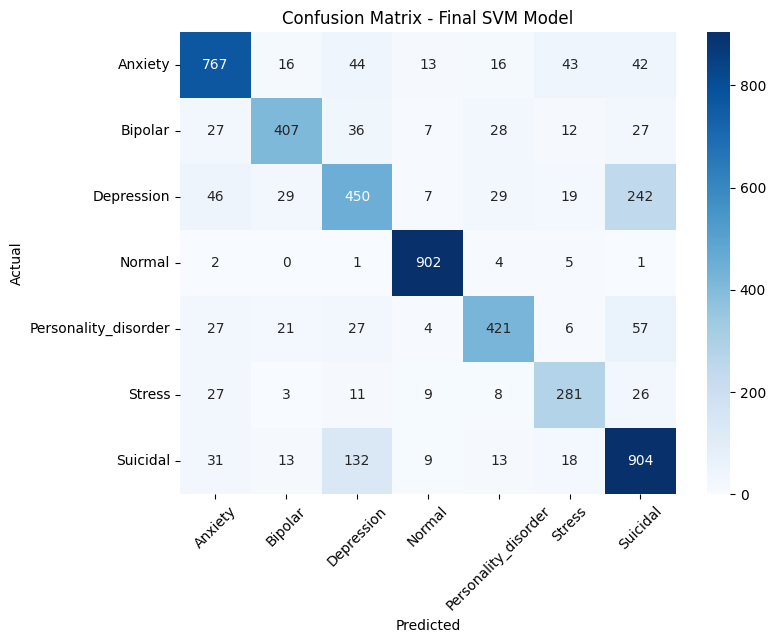

In [67]:
from sklearn.metrics import confusion_matrix
labels = ['Anxiety','Bipolar','Depression','Normal',
          'Personality_disorder','Stress','Suicidal']

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.title("Confusion Matrix - Final SVM Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Confusion Matrix Insights

- Strong performance on Normal and Anxiety  
- High recall for Suicidal class (important for safety)  
- Depression is often confused with Anxiety and Stress  

This shows difficulty in separating similar emotional states.